# Описание проекта

Вы работаете в фотохостинге для профессиональных фотографов «Со Смыслом» (“With Sense”). 

Ваши пользователи размещают свои фотографии на хостинге и сопровождают их полным описанием: указывают место съёмок, модель камеры и т. д. Отличительная особенность сервиса — описание: его может предоставить не только тот, кто размещает фотографию, но и другие пользователи портала. Например, для этой фотографии

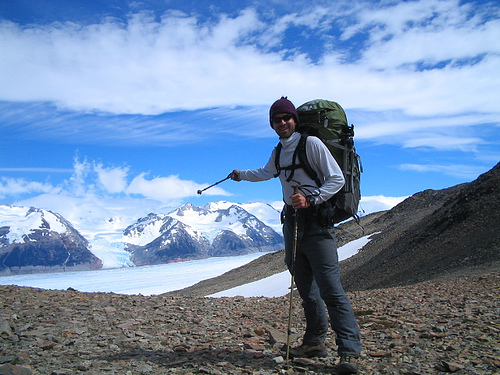

Описание выглядит так: *A hiker poses for a picture in front of stunning mountains and clouds. (Турист позирует для фотосессии на фоне потрясающих гор и облаков)*

Ваш отдел занимается экспериментом по разработке поиска референсных фотографий для фотографов. Суть поиска заключается в следующем: пользователь сервиса вводит описание нужной сцены.

Например, такое: *A man is crossing a mountain pass on a metal bridge. (Мужчина пересекает горный перевал по металлическому мосту)*
Сервис выводит несколько фотографий с такой же или похожей сценой.

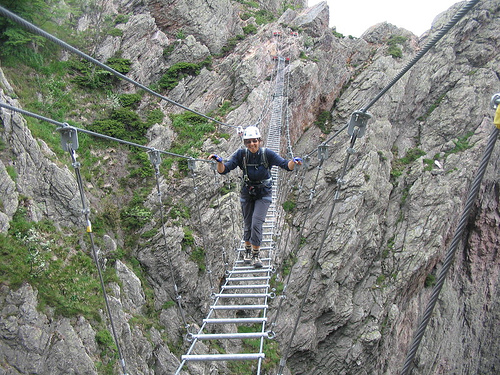

Чтобы эксперимент получил право на жизнь, нужно защитить его перед руководителем компании. Для защиты необходимо презентовать так называемый PoC (Proof of Concept, Проверка концепции) — продемонстрировать, что такой проект практически осуществим. Вам поручено разработать демонстрационную версию поиска изображений по запросу.

Для демонстрационной версии нужно выбрать лучшую  модель, которая получит векторное представление изображения, векторное представление текста, а на выходе выдаст число от 0 до 1 — и покажет, насколько текст и картинка подходят друг другу. 
На основе лучшей модели можно будет собрать предварительную версию продукта, которую вы покажете руководителю компании.

### Юридические ограничения

В некоторых странах, где работает компания With Sense, действуют ограничения по обработке изображений: поисковым сервисам и сервисам, предоставляющим возможность поиска, запрещено без разрешения родителей или законных представителей предоставлять любую информацию, в том числе, но не исключительно, текстов, изображений, видео и аудио, содержащие описание, изображение или запись голоса детей. Ребёнком считается любой человек, не достигший 16-ти лет.

В вашем сервисе строго следуют законам стран, в которых работают. Поэтому при попытке посмотреть изображения, запрещённые законодательством, вместо картинок показывается дисклеймер:

**This image is unavailable in your country in compliance with local laws. (Это изображение недоступно в вашей стране в соответствии с местным законодательством)**

Однако у вас в PoC нет возможности воспользоваться данным функционалом. Поэтому необходимо очистить данные от проблемного контента. Во время тестирования модели при появлении в запросе “вредного” контента должен отображаться дисклеймер. 

### Описание данных

В файле **train_dataset.csv** собрана информация, необходимая для обучения: имя файла изображения, идентификатор описания и текст описания. Для одной картинки может быть доступно до 5 описаний. Идентификатор описания имеет формат <имя файла изображения>#<порядковый номер описания>.

В папке **train_images** содержатся изображения для тренировки модели.

В файле **CrowdAnnotations.tsv** — данные по соответствию изображения и описания, полученные с помощью краудсорсинга. Номера колонок и соответствующий тип данных:
- Имя файла изображения.
- Идентификатор описания.
- Доля людей, подтвердивших, что описание соответствует изображению.
- Количество человек, подтвердивших, что описание соответствует изображению.
- Количество человек, подтвердивших, что описание не соответствует изображению.

В файле **ExpertAnnotations.tsv** содержатся данные по соответствию изображения и описания, полученные в результате опроса экспертов. Номера колонок и соответствующий тип данных:
- Имя файла изображения.
- Идентификатор описания.
- 3, 4, 5 — оценки трёх экспертов. Эксперты ставят оценки по шкале от 1 до 4, где 1 — изображение и запрос совершенно не соответствуют друг другу, 2 — запрос содержит элементы описания изображения, но в целом запрос тексту не соответствует, 3 — запрос и текст соответствуют с точностью до некоторых деталей, 4 — запрос и текст соответствуют полностью.

В файле **test_queries.csv** находится информация, необходимая для тестирования: идентификатор запроса, текст запроса и релевантное изображение. Для одной картинки может быть доступно до 5 описаний. Идентификатор описания имеет формат <имя файла изображения>#<порядковый номер описания>.

В папке **test_images** содержатся изображения для тестирования модели.

# Импорты и константы

In [1]:
import os
import warnings
import time

from PIL import Image
from pathlib import Path

import torch 
import torch.nn as nn
import snntorch as snn
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

import math
from scipy import stats as st
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import random

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import LogisticRegression, LinearRegression, Ridge
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.metrics import accuracy_score, log_loss, f1_score, mean_squared_error

import re
import nltk
from nltk.stem import WordNetLemmatizer
from nltk.corpus import stopwords as nltk_stopwords
from sklearn.feature_extraction.text import TfidfVectorizer

import glob

c:\Users\Rog\anaconda3\envs\base_2\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
PATH = 'C:\\Users\\Rog\\Desktop\\Programing\\Yandex\\'
WORD_TO_BLOCK = ['child', 'boy', 'girl', 'baby', 'teen', 'teenager', 'kid', 'infant', 'youngster', 'kids', 'children', 'boys', 'girls', 'babies', 'teens', 'teenagers']

In [3]:
train_data = pd.read_csv(os.path.join(PATH, 'data/train_dataset.csv'))
train_data.name = 'train_data'
data_crowd = pd.read_csv(os.path.join(PATH, 'data/CrowdAnnotations.tsv'), sep='\t', names = ['image', 'query_id', 'fraction', 'pros', 'cons'])
data_crowd.name = 'data_crowd'
data_expert = pd.read_csv(os.path.join(PATH, 'data/ExpertAnnotations.tsv'), sep='\t', names = ['image', 'query_id', 'first', 'second', 'third'])
data_expert.name = 'data_expert'
test_query = pd.read_csv(os.path.join(PATH, 'data/test_queries.csv'), index_col=[0], sep='|')
test_query.name = 'test_query'
test_image = pd.read_csv(os.path.join(PATH, 'data/test_images.csv'))
test_image.name = 'test_image'

In [4]:
for dataframe in [train_data, data_crowd, data_expert, test_query, test_image]:
    print('------------------------------------------------------------------------------------------------------------')
    print('+-------------+')
    print(f'| {dataframe.name}  |')
    print('+-------------+')
    print(dataframe.shape)
    display(dataframe.head(5))
    print()

------------------------------------------------------------------------------------------------------------
+-------------+
| train_data  |
+-------------+
(5822, 3)


,image,query_id,query_text
0,1056338697_4f7d7ce270.jpg,2549968784_39bfbe44f9.jpg#2,A young child is wearing blue goggles and sitt...
1,1262583859_653f1469a9.jpg,2549968784_39bfbe44f9.jpg#2,A young child is wearing blue goggles and sitt...
2,2447284966_d6bbdb4b6e.jpg,2549968784_39bfbe44f9.jpg#2,A young child is wearing blue goggles and sitt...
3,2549968784_39bfbe44f9.jpg,2549968784_39bfbe44f9.jpg#2,A young child is wearing blue goggles and sitt...
4,2621415349_ef1a7e73be.jpg,2549968784_39bfbe44f9.jpg#2,A young child is wearing blue goggles and sitt...



------------------------------------------------------------------------------------------------------------
+-------------+
| data_crowd  |
+-------------+
(47830, 5)


,image,query_id,fraction,pros,cons
0,1056338697_4f7d7ce270.jpg,1056338697_4f7d7ce270.jpg#2,1.0,3,0
1,1056338697_4f7d7ce270.jpg,114051287_dd85625a04.jpg#2,0.0,0,3
2,1056338697_4f7d7ce270.jpg,1427391496_ea512cbe7f.jpg#2,0.0,0,3
3,1056338697_4f7d7ce270.jpg,2073964624_52da3a0fc4.jpg#2,0.0,0,3
4,1056338697_4f7d7ce270.jpg,2083434441_a93bc6306b.jpg#2,0.0,0,3



------------------------------------------------------------------------------------------------------------
+-------------+
| data_expert  |
+-------------+
(5822, 5)


,image,query_id,first,second,third
0,1056338697_4f7d7ce270.jpg,2549968784_39bfbe44f9.jpg#2,1,1,1
1,1056338697_4f7d7ce270.jpg,2718495608_d8533e3ac5.jpg#2,1,1,2
2,1056338697_4f7d7ce270.jpg,3181701312_70a379ab6e.jpg#2,1,1,2
3,1056338697_4f7d7ce270.jpg,3207358897_bfa61fa3c6.jpg#2,1,2,2
4,1056338697_4f7d7ce270.jpg,3286822339_5535af6b93.jpg#2,1,1,2



------------------------------------------------------------------------------------------------------------
+-------------+
| test_query  |
+-------------+
(500, 3)


,query_id,query_text,image
0,1177994172_10d143cb8d.jpg#0,"Two blonde boys , one in a camouflage shirt an...",1177994172_10d143cb8d.jpg
1,1177994172_10d143cb8d.jpg#1,Two boys are squirting water guns at each other .,1177994172_10d143cb8d.jpg
2,1177994172_10d143cb8d.jpg#2,Two boys spraying each other with water,1177994172_10d143cb8d.jpg
3,1177994172_10d143cb8d.jpg#3,Two children wearing jeans squirt water at eac...,1177994172_10d143cb8d.jpg
4,1177994172_10d143cb8d.jpg#4,Two young boys are squirting water at each oth...,1177994172_10d143cb8d.jpg



------------------------------------------------------------------------------------------------------------
+-------------+
| test_image  |
+-------------+
(100, 1)


,image
0,3356748019_2251399314.jpg
1,2887171449_f54a2b9f39.jpg
2,3089107423_81a24eaf18.jpg
3,1429546659_44cb09cbe2.jpg
4,1177994172_10d143cb8d.jpg


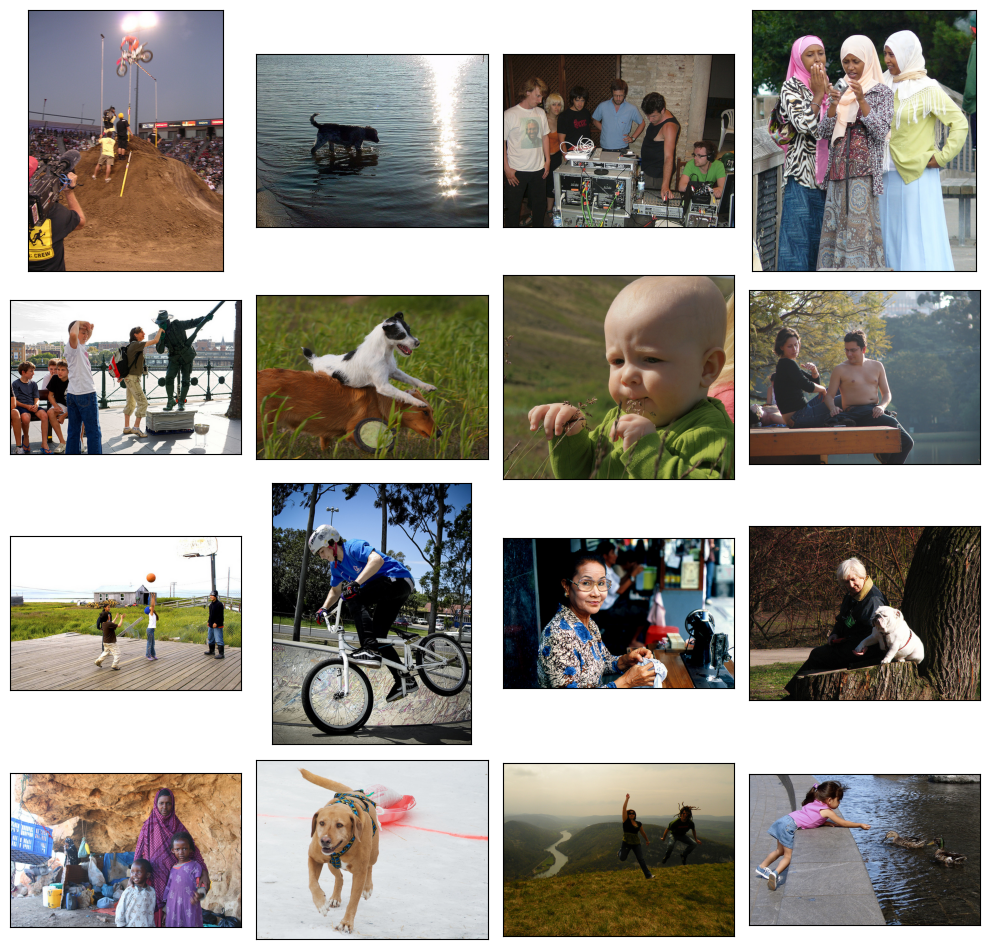

In [5]:
samples_train = list(train_data['image'].sample(8))
samples_test = list(test_query['image'].sample(8))

fig = plt.figure(figsize=(10,10))
for i in range(8):
    fig.add_subplot(4, 4, i+1)
    image = Image.open(Path(PATH, 'data/to_upload/train_images', samples_train[i]))
    plt.imshow(image)
    plt.xticks([])
    plt.yticks([])
    plt.tight_layout()
for i in range(8):
    fig.add_subplot(4, 4, i+9)
    image = Image.open(Path(PATH, 'data/to_upload/test_images', samples_test[i]))
    plt.imshow(image)
    plt.xticks([])
    plt.yticks([])
    plt.tight_layout()

### Агрегирование картинок

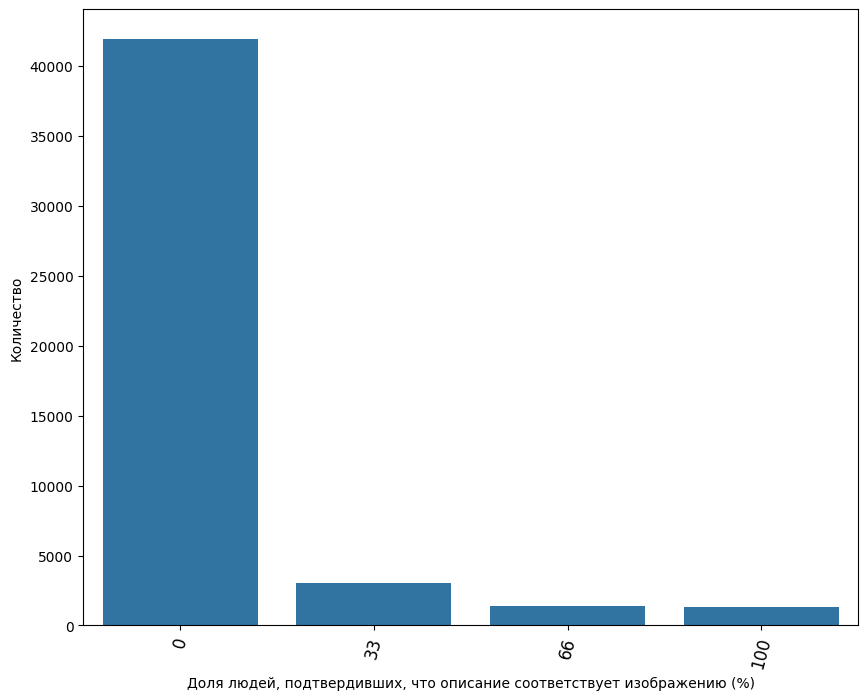

In [6]:
crowd_analicit = data_crowd.copy()
crowd_analicit['fraction'] *= 100
crowd_analicit['fraction'] = crowd_analicit['fraction'].astype('int')
crowd_array=[]
fraction_nums = np.array([0, 33, 66, 100])
for i in fraction_nums:
    crowd_array.append((crowd_analicit['fraction'] == i).sum())
    
plt.figure(figsize=(10, 8))
sns.barplot(x = fraction_nums, y = crowd_array)
plt.xticks(rotation=75, size=12)
plt.xlabel('Доля людей, подтвердивших, что описание соответствует изображению (%)')
plt.ylabel('Количество')
plt.show()

In [7]:
def transform_range(x):
    return round((x - 1) / 3.0, 2)

def agr_data(row):

    if row['first'] != row['second'] != row['third']:
        row['agr_expert'] = (row['first'] + row['second'] + row['third']) // 3
    else:
        row['agr_expert'] = int(np.median(row['first':'third']))
    
    return row
    
data_expert = data_expert.apply(agr_data, axis=1)
data_expert

,image,query_id,first,second,third,agr_expert
0,1056338697_4f7d7ce270.jpg,2549968784_39bfbe44f9.jpg#2,1,1,1,1
1,1056338697_4f7d7ce270.jpg,2718495608_d8533e3ac5.jpg#2,1,1,2,1
2,1056338697_4f7d7ce270.jpg,3181701312_70a379ab6e.jpg#2,1,1,2,1
3,1056338697_4f7d7ce270.jpg,3207358897_bfa61fa3c6.jpg#2,1,2,2,2
4,1056338697_4f7d7ce270.jpg,3286822339_5535af6b93.jpg#2,1,1,2,1
...,...,...,...,...,...,...
5817,997722733_0cb5439472.jpg,2981702521_2459f2c1c4.jpg#2,1,1,1,1
5818,997722733_0cb5439472.jpg,2985679744_75a7102aab.jpg#2,1,1,1,1
5819,997722733_0cb5439472.jpg,3150742439_b8a352e1e0.jpg#2,1,1,2,1
5820,997722733_0cb5439472.jpg,3375070563_3c290a7991.jpg#2,1,1,1,1


In [8]:
agr_expert_unique = data_expert.agr_expert.unique()
agr_expert_unique

array([1, 2, 3, 4], dtype=int64)

In [9]:
data_merged = data_expert.merge(data_crowd, on = ['image', 'query_id'], how='outer')
data_merged

,image,query_id,first,second,third,agr_expert,fraction,pros,cons
0,1056338697_4f7d7ce270.jpg,2549968784_39bfbe44f9.jpg#2,1.0,1.0,1.0,1.0,0.000000,0.0,3.0
1,1056338697_4f7d7ce270.jpg,2718495608_d8533e3ac5.jpg#2,1.0,1.0,2.0,1.0,0.000000,0.0,3.0
2,1056338697_4f7d7ce270.jpg,3181701312_70a379ab6e.jpg#2,1.0,1.0,2.0,1.0,NaN,NaN,NaN
3,1056338697_4f7d7ce270.jpg,3207358897_bfa61fa3c6.jpg#2,1.0,2.0,2.0,2.0,NaN,NaN,NaN
4,1056338697_4f7d7ce270.jpg,3286822339_5535af6b93.jpg#2,1.0,1.0,2.0,1.0,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...
51318,997722733_0cb5439472.jpg,543007912_23fc735b99.jpg#2,NaN,NaN,NaN,NaN,0.000000,0.0,3.0
51319,997722733_0cb5439472.jpg,544576742_283b65fa0d.jpg#2,NaN,NaN,NaN,NaN,0.333333,1.0,2.0
51320,997722733_0cb5439472.jpg,872622575_ba1d3632cc.jpg#2,NaN,NaN,NaN,NaN,1.000000,3.0,0.0
51321,997722733_0cb5439472.jpg,888425986_e4b6c12324.jpg#2,NaN,NaN,NaN,NaN,0.000000,0.0,3.0


In [10]:
warnings.filterwarnings('ignore')

print('Количество NaN значений после объеденений массивов в agr_expert:', data_merged.isna().sum()[2])
print('Количество NaN значений после объеденений массивов в fraction:', data_merged.isna().sum()[3])
print()
print('Матрица корреляции agr_expert и fraction:')
display(data_merged[['agr_expert', 'fraction']].corr())

Количество NaN значений после объеденений массивов в agr_expert: 45501
Количество NaN значений после объеденений массивов в fraction: 45501

Матрица корреляции agr_expert и fraction:


,agr_expert,fraction
agr_expert,1.000000,0.762474
fraction,0.762474,1.000000


In [11]:
data_merged_notnan = data_merged.copy()
data_merged_notnan = data_merged_notnan.dropna()

for i in agr_expert_unique:
    print(f'Средняя доля людей, подтвердивших, что описание соответствует изображению (%) при оценке экспертов равной {i}:',
          '{:.0%}'.format(data_merged_notnan.loc[data_merged_notnan['agr_expert'] == i, 'fraction'].mean()),
          ', std:',
          '{:.0%}'.format(data_merged_notnan.loc[data_merged_notnan['agr_expert'] == i, 'fraction'].std()))
    
print()
print('Подсчёт уникальных значений столбца agr_expert')
print(data_merged_notnan.agr_expert.value_counts())
print()
print('Подсчёт уникальных значений столбца fraction')
print(data_merged_notnan.fraction.value_counts())

Средняя доля людей, подтвердивших, что описание соответствует изображению (%) при оценке экспертов равной 1: 0% , std: 3%
Средняя доля людей, подтвердивших, что описание соответствует изображению (%) при оценке экспертов равной 2: 5% , std: 14%
Средняя доля людей, подтвердивших, что описание соответствует изображению (%) при оценке экспертов равной 3: 31% , std: 32%
Средняя доля людей, подтвердивших, что описание соответствует изображению (%) при оценке экспертов равной 4: 89% , std: 20%

Подсчёт уникальных значений столбца agr_expert
agr_expert
2.0    957
1.0    604
3.0    463
4.0    305
Name: count, dtype: int64

Подсчёт уникальных значений столбца fraction
fraction
0.000000    1633
1.000000     263
0.333333     257
0.666667     158
0.250000       6
0.500000       4
0.200000       2
0.400000       2
0.800000       2
0.750000       2
Name: count, dtype: int64


##### Заполнение NaN для agr_expert

In [12]:
def agr_merge(row):
    if row['fraction'] >= 0.75:
        return 4.0
    elif row['fraction'] >= 0.25:
        return 3.0
    elif row['fraction'] >= 0.10:
        return 2.0
    return 1.0

In [13]:
features_func = data_merged[['agr_expert', 'fraction']].copy()
features_func.dropna(inplace=True)
features_func['predict'] = features_func.apply(agr_merge, axis=1)

agr_expert_models = pd.DataFrame(columns = ['ACC'])

def alter_table(df, model_name, acc):
    '''Добавляет в нашу таблицу с анализом моделей данные'''
    
    agr_expert_models.loc[model_name, 'ACC'] = acc
    
    return df


alter_table(agr_expert_models,
            'BaseLine',
            round(accuracy_score(features_func['predict'], features_func['agr_expert']), 4))

,ACC
BaseLine,0.4538


In [14]:
data_merged_expert = data_merged.copy()
data_merged_expert.dropna(inplace=True)

features = data_merged_expert[['fraction', 'pros', 'cons']]
target = data_merged_expert.agr_expert

print(features.shape)
print(target.shape)

(2329, 3)
(2329,)


In [15]:
features_train, features_test, target_train, target_test = train_test_split(features,
                                                                            target,
                                                                            test_size=0.25,
                                                                            random_state=12345)

In [16]:
model_lr = LogisticRegression(class_weight="balanced", random_state=12345).fit(features_train, target_train)
predictions = model_lr.predict(features_test)

alter_table(agr_expert_models,
            'LogisticRegression',
            round(accuracy_score(predictions, target_test), 4))

,ACC
BaseLine,0.4538
LogisticRegression,0.4511


In [17]:
model_svc = SVC(class_weight="balanced", kernel = 'sigmoid').fit(features_train, target_train)
predictions = model_svc.predict(features_test)

alter_table(agr_expert_models,
            'SVC',
            round(accuracy_score(predictions, target_test), 4))

,ACC
BaseLine,0.4538
LogisticRegression,0.4511
SVC,0.4597


In [18]:
model_rfc = RandomForestClassifier(class_weight="balanced").fit(features_train, target_train)
predictions = model_rfc.predict(features_test)

alter_table(agr_expert_models,
            'RandomForestClassifier',
            round(accuracy_score(predictions, target_test), 4))

,ACC
BaseLine,0.4538
LogisticRegression,0.4511
SVC,0.4597
RandomForestClassifier,0.4494


In [19]:
agr_expert_models.sort_values(by='ACC', ascending = False)

,ACC
SVC,0.4597
BaseLine,0.4538
LogisticRegression,0.4511
RandomForestClassifier,0.4494


##### Заполнение NaN для fraction

In [20]:
fraction_models = pd.DataFrame(columns = ['RMSE'])

def alter_table(df, model_name, rmse):
    fraction_models.loc[model_name, 'RMSE'] = rmse
    
    return df

In [21]:
features = data_merged_expert[['first', 'second', 'third', 'agr_expert']]
target = data_merged_expert.fraction

print(features.shape)
print(target.shape)

(2329, 4)
(2329,)


In [22]:
features_train, features_test, target_train, target_test = train_test_split(features,
                                                                            target,
                                                                            test_size=0.25,
                                                                            random_state=12345)

In [23]:
model_lr = LinearRegression().fit(features_train, target_train)
predictions = model_lr.predict(features_test)

alter_table(alter_table,
            'LinearRegression',
            round(np.sqrt(mean_squared_error(target_test, predictions)), 4))
fraction_models

,RMSE
LinearRegression,0.2132


In [24]:
model_r = Ridge().fit(features_train, target_train)
predictions = model_r.predict(features_test)

alter_table(alter_table,
            'Ridge',
            round(np.sqrt(mean_squared_error(target_test, predictions)), 4))
fraction_models

,RMSE
LinearRegression,0.2132
Ridge,0.2132


In [25]:
model_rfr = RandomForestRegressor().fit(features_train, target_train)
predictions = model_rfr.predict(features_test)

alter_table(alter_table,
            'RandomForestRegressor',
            round(np.sqrt(mean_squared_error(target_test, predictions)), 4))
fraction_models.sort_values(by='RMSE')

,RMSE
RandomForestRegressor,0.1787
LinearRegression,0.2132
Ridge,0.2132


In [26]:
grid_params = {'n_estimators': np.arange(50, 110, 10),
               'max_depth': np.arange(9, 16),
               'criterion': ['squared_error', 'absolute_error']}

grid = GridSearchCV(RandomForestRegressor(n_jobs=6), grid_params, cv=3, verbose=1, error_score='raise', n_jobs=2).fit(features_train, target_train)

model_cv = grid.best_estimator_

Fitting 3 folds for each of 84 candidates, totalling 252 fits


In [27]:
predictions = model_cv.predict(features_test)
print(np.sqrt(mean_squared_error(target_test, predictions)))

0.17915362017637057


##### Заполнение

In [28]:
data_merged

,image,query_id,first,second,third,agr_expert,fraction,pros,cons
0,1056338697_4f7d7ce270.jpg,2549968784_39bfbe44f9.jpg#2,1.0,1.0,1.0,1.0,0.000000,0.0,3.0
1,1056338697_4f7d7ce270.jpg,2718495608_d8533e3ac5.jpg#2,1.0,1.0,2.0,1.0,0.000000,0.0,3.0
2,1056338697_4f7d7ce270.jpg,3181701312_70a379ab6e.jpg#2,1.0,1.0,2.0,1.0,NaN,NaN,NaN
3,1056338697_4f7d7ce270.jpg,3207358897_bfa61fa3c6.jpg#2,1.0,2.0,2.0,2.0,NaN,NaN,NaN
4,1056338697_4f7d7ce270.jpg,3286822339_5535af6b93.jpg#2,1.0,1.0,2.0,1.0,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...
51318,997722733_0cb5439472.jpg,543007912_23fc735b99.jpg#2,NaN,NaN,NaN,NaN,0.000000,0.0,3.0
51319,997722733_0cb5439472.jpg,544576742_283b65fa0d.jpg#2,NaN,NaN,NaN,NaN,0.333333,1.0,2.0
51320,997722733_0cb5439472.jpg,872622575_ba1d3632cc.jpg#2,NaN,NaN,NaN,NaN,1.000000,3.0,0.0
51321,997722733_0cb5439472.jpg,888425986_e4b6c12324.jpg#2,NaN,NaN,NaN,NaN,0.000000,0.0,3.0


In [29]:
def fill_nan(row):
    if np.isnan(row['agr_expert']):
        a = model_svc.predict([[row['fraction'], row['pros'], row['cons']]])[0]
        row['agr_expert'] = a
    elif np.isnan(row['fraction']):
        b = np.round((model_cv.predict([[row['first'], row['second'], row['third'], row['agr_expert']]]))[0], 6)
        row['fraction'] = b

    return row

data_merged = data_merged.apply(fill_nan, axis=1)
data_merged

,image,query_id,first,second,third,agr_expert,fraction,pros,cons
0,1056338697_4f7d7ce270.jpg,2549968784_39bfbe44f9.jpg#2,1.0,1.0,1.0,1.0,0.000000,0.0,3.0
1,1056338697_4f7d7ce270.jpg,2718495608_d8533e3ac5.jpg#2,1.0,1.0,2.0,1.0,0.000000,0.0,3.0
2,1056338697_4f7d7ce270.jpg,3181701312_70a379ab6e.jpg#2,1.0,1.0,2.0,1.0,0.002051,NaN,NaN
3,1056338697_4f7d7ce270.jpg,3207358897_bfa61fa3c6.jpg#2,1.0,2.0,2.0,2.0,0.014316,NaN,NaN
4,1056338697_4f7d7ce270.jpg,3286822339_5535af6b93.jpg#2,1.0,1.0,2.0,1.0,0.002051,NaN,NaN
...,...,...,...,...,...,...,...,...,...
51318,997722733_0cb5439472.jpg,543007912_23fc735b99.jpg#2,NaN,NaN,NaN,1.0,0.000000,0.0,3.0
51319,997722733_0cb5439472.jpg,544576742_283b65fa0d.jpg#2,NaN,NaN,NaN,3.0,0.333333,1.0,2.0
51320,997722733_0cb5439472.jpg,872622575_ba1d3632cc.jpg#2,NaN,NaN,NaN,4.0,1.000000,3.0,0.0
51321,997722733_0cb5439472.jpg,888425986_e4b6c12324.jpg#2,NaN,NaN,NaN,1.0,0.000000,0.0,3.0


In [30]:
data_merged.shape[0]

51323

In [31]:
for i in range(data_merged.shape[0]):
    data_merged.iloc[i, data_merged.columns.get_loc('agr_expert')] = round((data_merged.iloc[i]['agr_expert'] - 1) / 3.0, 2)
    
data_merged

,image,query_id,first,second,third,agr_expert,fraction,pros,cons
0,1056338697_4f7d7ce270.jpg,2549968784_39bfbe44f9.jpg#2,1.0,1.0,1.0,0.00,0.000000,0.0,3.0
1,1056338697_4f7d7ce270.jpg,2718495608_d8533e3ac5.jpg#2,1.0,1.0,2.0,0.00,0.000000,0.0,3.0
2,1056338697_4f7d7ce270.jpg,3181701312_70a379ab6e.jpg#2,1.0,1.0,2.0,0.00,0.002051,NaN,NaN
3,1056338697_4f7d7ce270.jpg,3207358897_bfa61fa3c6.jpg#2,1.0,2.0,2.0,0.33,0.014316,NaN,NaN
4,1056338697_4f7d7ce270.jpg,3286822339_5535af6b93.jpg#2,1.0,1.0,2.0,0.00,0.002051,NaN,NaN
...,...,...,...,...,...,...,...,...,...
51318,997722733_0cb5439472.jpg,543007912_23fc735b99.jpg#2,NaN,NaN,NaN,0.00,0.000000,0.0,3.0
51319,997722733_0cb5439472.jpg,544576742_283b65fa0d.jpg#2,NaN,NaN,NaN,0.67,0.333333,1.0,2.0
51320,997722733_0cb5439472.jpg,872622575_ba1d3632cc.jpg#2,NaN,NaN,NaN,1.00,1.000000,3.0,0.0
51321,997722733_0cb5439472.jpg,888425986_e4b6c12324.jpg#2,NaN,NaN,NaN,0.00,0.000000,0.0,3.0


In [32]:
data_merged.agr_expert.unique()

array([0.  , 0.33, 0.67, 1.  ])

In [33]:
data_merged.dropna(axis=1, inplace=True)
data_merged

,image,query_id,agr_expert,fraction
0,1056338697_4f7d7ce270.jpg,2549968784_39bfbe44f9.jpg#2,0.00,0.000000
1,1056338697_4f7d7ce270.jpg,2718495608_d8533e3ac5.jpg#2,0.00,0.000000
2,1056338697_4f7d7ce270.jpg,3181701312_70a379ab6e.jpg#2,0.00,0.002051
3,1056338697_4f7d7ce270.jpg,3207358897_bfa61fa3c6.jpg#2,0.33,0.014316
4,1056338697_4f7d7ce270.jpg,3286822339_5535af6b93.jpg#2,0.00,0.002051
...,...,...,...,...
51318,997722733_0cb5439472.jpg,543007912_23fc735b99.jpg#2,0.00,0.000000
51319,997722733_0cb5439472.jpg,544576742_283b65fa0d.jpg#2,0.67,0.333333
51320,997722733_0cb5439472.jpg,872622575_ba1d3632cc.jpg#2,1.00,1.000000
51321,997722733_0cb5439472.jpg,888425986_e4b6c12324.jpg#2,0.00,0.000000


In [34]:
def scoring(row):
    row['score'] = row['agr_expert'] * 0.75 + row['fraction']*0.25
    return row

data_merged = data_merged.apply(scoring, axis=1)
display(data_merged)
display(data_merged.describe())

,image,query_id,agr_expert,fraction,score
0,1056338697_4f7d7ce270.jpg,2549968784_39bfbe44f9.jpg#2,0.00,0.000000,0.000000
1,1056338697_4f7d7ce270.jpg,2718495608_d8533e3ac5.jpg#2,0.00,0.000000,0.000000
2,1056338697_4f7d7ce270.jpg,3181701312_70a379ab6e.jpg#2,0.00,0.002051,0.000513
3,1056338697_4f7d7ce270.jpg,3207358897_bfa61fa3c6.jpg#2,0.33,0.014316,0.251079
4,1056338697_4f7d7ce270.jpg,3286822339_5535af6b93.jpg#2,0.00,0.002051,0.000513
...,...,...,...,...,...
51318,997722733_0cb5439472.jpg,543007912_23fc735b99.jpg#2,0.00,0.000000,0.000000
51319,997722733_0cb5439472.jpg,544576742_283b65fa0d.jpg#2,0.67,0.333333,0.585833
51320,997722733_0cb5439472.jpg,872622575_ba1d3632cc.jpg#2,1.00,1.000000,1.000000
51321,997722733_0cb5439472.jpg,888425986_e4b6c12324.jpg#2,0.00,0.000000,0.000000


,agr_expert,fraction,score
count,51323.000000,51323.000000,51323.000000
mean,0.103048,0.065005,0.093538
std,0.248727,0.201263,0.232788
min,0.000000,0.000000,0.000000
25%,0.000000,0.000000,0.000000
50%,0.000000,0.000000,0.000000
75%,0.000000,0.000000,0.000000
max,1.000000,1.000000,1.000000


In [35]:
train_data = pd.merge(train_data, data_merged[['image', 'query_id', 'score']], how='outer', on=['image', 'query_id'])

In [36]:
train_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 51323 entries, 0 to 51322
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   image       51323 non-null  object 
 1   query_id    51323 non-null  object 
 2   query_text  5822 non-null   object 
 3   score       51323 non-null  float64
dtypes: float64(1), object(3)
memory usage: 1.6+ MB


In [37]:
notna_train = train_data[train_data['query_text'].notna()]
notna_train

,image,query_id,query_text,score
0,1056338697_4f7d7ce270.jpg,2549968784_39bfbe44f9.jpg#2,A young child is wearing blue goggles and sitt...,0.000000
1,1262583859_653f1469a9.jpg,2549968784_39bfbe44f9.jpg#2,A young child is wearing blue goggles and sitt...,0.000305
2,2447284966_d6bbdb4b6e.jpg,2549968784_39bfbe44f9.jpg#2,A young child is wearing blue goggles and sitt...,0.247500
3,2549968784_39bfbe44f9.jpg,2549968784_39bfbe44f9.jpg#2,A young child is wearing blue goggles and sitt...,1.000000
4,2621415349_ef1a7e73be.jpg,2549968784_39bfbe44f9.jpg#2,A young child is wearing blue goggles and sitt...,0.000305
...,...,...,...,...
5817,757046028_ff5999f91b.jpg,2061144717_5b3a1864f0.jpg#2,A man in an ampitheater talking to a boy .,0.330833
5818,799486353_f665d7b0f0.jpg,2196107384_361d73a170.jpg#2,a old man walks down the uncrowded road .,0.000305
5819,909808296_23c427022d.jpg,2112921744_92bf706805.jpg#2,A dog stands on the side of a grassy cliff .,0.256112
5820,929679367_ff8c7df2ee.jpg,3651971126_309e6a5e22.jpg#2,A blurry photo of two dogs .,0.502500


In [38]:
idx = 5855
print(train_data.iloc[idx])
qid = train_data.iloc[idx]['query_id']
notna_train.loc[notna_train['query_id'] == qid]['query_text']

image           1056338697_4f7d7ce270.jpg
query_id      3499720588_c32590108e.jpg#2
query_text                            NaN
score                                 0.0
Name: 5855, dtype: object


Series([], Name: query_text, dtype: object)

In [39]:
def fillna_train(row):
    
    if pd.isnull(row['query_text']):
        text = notna_train[notna_train['query_id'] == row['query_id']]['query_text']
        if len(text) != 0:
            row['query_text'] = text.iloc[0]
    return row

train_data = train_data.apply(fillna_train, axis=1)

In [40]:
train_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 51323 entries, 0 to 51322
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   image       51323 non-null  object 
 1   query_id    51323 non-null  object 
 2   query_text  50214 non-null  object 
 3   score       51323 non-null  float64
dtypes: float64(1), object(3)
memory usage: 1.6+ MB


In [41]:
train_data.dropna(inplace=True)
display(train_data.head(10))
train_data.info()

,image,query_id,query_text,score
0,1056338697_4f7d7ce270.jpg,2549968784_39bfbe44f9.jpg#2,A young child is wearing blue goggles and sitt...,0.000000
1,1262583859_653f1469a9.jpg,2549968784_39bfbe44f9.jpg#2,A young child is wearing blue goggles and sitt...,0.000305
2,2447284966_d6bbdb4b6e.jpg,2549968784_39bfbe44f9.jpg#2,A young child is wearing blue goggles and sitt...,0.247500
3,2549968784_39bfbe44f9.jpg,2549968784_39bfbe44f9.jpg#2,A young child is wearing blue goggles and sitt...,1.000000
4,2621415349_ef1a7e73be.jpg,2549968784_39bfbe44f9.jpg#2,A young child is wearing blue goggles and sitt...,0.000305
5,3030566410_393c36a6c5.jpg,2549968784_39bfbe44f9.jpg#2,A young child is wearing blue goggles and sitt...,0.247500
6,3155451946_c0862c70cb.jpg,2549968784_39bfbe44f9.jpg#2,A young child is wearing blue goggles and sitt...,0.000305
7,3222041930_f642f49d28.jpg,2549968784_39bfbe44f9.jpg#2,A young child is wearing blue goggles and sitt...,0.000305
8,343218198_1ca90e0734.jpg,2549968784_39bfbe44f9.jpg#2,A young child is wearing blue goggles and sitt...,0.000305
9,3718964174_cb2dc1615e.jpg,2549968784_39bfbe44f9.jpg#2,A young child is wearing blue goggles and sitt...,0.000000


<class 'pandas.core.frame.DataFrame'>
Index: 50214 entries, 0 to 51322
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   image       50214 non-null  object 
 1   query_id    50214 non-null  object 
 2   query_text  50214 non-null  object 
 3   score       50214 non-null  float64
dtypes: float64(1), object(3)
memory usage: 1.9+ MB


In [42]:
limit = 0.7
limit_data = train_data.loc[train_data['score'] > limit]
display(limit_data)

,image,query_id,query_text,score
3,2549968784_39bfbe44f9.jpg,2549968784_39bfbe44f9.jpg#2,A young child is wearing blue goggles and sitt...,1.0
16,2718495608_d8533e3ac5.jpg,2718495608_d8533e3ac5.jpg#2,A girl wearing a yellow shirt and sunglasses s...,1.0
74,1425069308_488e5fcf9d.jpg,1425069308_488e5fcf9d.jpg#2,A white dog jumps to catch a blue ball in a li...,1.0
86,2140182410_8e2a06fbda.jpg,2140182410_8e2a06fbda.jpg#2,The kid is on a float in the snow .,1.0
110,3119076670_64b5340530.jpg,3119076670_64b5340530.jpg#2,Snowboarder in the air performing a stunt .,1.0
...,...,...,...,...
51046,925491651_57df3a5b36.jpg,1772859261_236c09b861.jpg#2,A dog splashes through the water .,1.0
51062,925491651_57df3a5b36.jpg,2541104331_a2d65cfa54.jpg#2,a dog pounces into the water .,1.0
51152,929679367_ff8c7df2ee.jpg,929679367_ff8c7df2ee.jpg#2,A puppy is playing with a tennis ball on a wel...,1.0
51238,968081289_cdba83ce2e.jpg,968081289_cdba83ce2e.jpg#2,Two boys jumping off the pier into the water .,1.0


### Вывод

Были агрегированны экспертные оценки и оценки пользователей. Теперь все приведено к общему виду

# Проверка данных

In [43]:
train_data.iloc[5682]['query_text']

'A woman skiing down a slope .'

In [44]:
l = WordNetLemmatizer()
stop_words = nltk_stopwords.words("english")
def lemmatize_text(phrase):
    
    phrase = re.sub('[^a-zA-Z]', ' ', phrase).lower()
    phrase = nltk.word_tokenize(phrase, language = 'english')
    phrase = [l.lemmatize(i, pos="n") for i in phrase]
    phrase = [l.lemmatize(i, pos="v") for i in phrase]
    phrase = [l.lemmatize(i, pos="a") for i in phrase]
    phrase = [l.lemmatize(i, pos="r") for i in phrase]
    phrase = [l.lemmatize(i, pos="s") for i in phrase]
    phrase = " ".join([i for i in phrase if i not in stop_words])
    return phrase


def blocking(row):
    
    phrase = lemmatize_text(row['query_text'])
    bin_array = [i for i in phrase if i in WORD_TO_BLOCK]
    if bin_array:
        row['word_to_block'] = 1
    else:
        row['word_to_block'] = 0
    
    return row

train_data = train_data.apply(blocking, axis=1)

In [45]:
train_data = train_data.loc[train_data['word_to_block'] == 0]
train_data.drop(columns=['word_to_block'], inplace=True)
train_data.head()

,image,query_id,query_text,score
0,1056338697_4f7d7ce270.jpg,2549968784_39bfbe44f9.jpg#2,A young child is wearing blue goggles and sitt...,0.000000
1,1262583859_653f1469a9.jpg,2549968784_39bfbe44f9.jpg#2,A young child is wearing blue goggles and sitt...,0.000305
2,2447284966_d6bbdb4b6e.jpg,2549968784_39bfbe44f9.jpg#2,A young child is wearing blue goggles and sitt...,0.247500
3,2549968784_39bfbe44f9.jpg,2549968784_39bfbe44f9.jpg#2,A young child is wearing blue goggles and sitt...,1.000000
4,2621415349_ef1a7e73be.jpg,2549968784_39bfbe44f9.jpg#2,A young child is wearing blue goggles and sitt...,0.000305


### Вывод

Были удалены фото с изображением детей из обучающей выборки

# Тренировка моделей

## Создание dataloader

In [46]:
train_data = train_data.reset_index(drop=True)
copy_train_data = train_data.copy()
copy_test_data = test_query.copy()
copy_test_data["score"] = 0

In [47]:
random_state = 12345
def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

set_seed(random_state)

In [48]:
device = "cuda" if torch.cuda.is_available() else "cpu"

In [49]:
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.Grayscale(num_output_channels=1),
    transforms.ToTensor(),
])

In [50]:
copy_train_data["query_text"] = copy_train_data["query_text"].apply(lambda x: lemmatize_text(x))
copy_test_data["query_text"] = copy_test_data["query_text"].apply(lambda x: lemmatize_text(x))

In [51]:
tokenizer = Tokenizer()
tokenizer.fit_on_texts(copy_train_data["query_text"])

In [52]:
class CustomDataset(torch.utils.data.Dataset):
    def __init__(self, data, path=None, train=True):
        self.train = train

        if self.train:
            self.images = data["image"]
            self.description = data["query_text"]
            self.target = data["score"]
            self.transform = transform
            self.path = path
            
        else:
            self.description = data["query_text"]


    def __len__(self):
        if self.train:
            return len(self.images)
        else:
            return len(self.description)

    def __getitem__(self, idx):
        if self.train:
            img_name = self.images.iloc[idx]
            image = Image.open(f"{self.path}{img_name}")
            tokens = torch.tensor(pad_sequences(tokenizer.texts_to_sequences([self.description.iloc[idx]]), maxlen=20)[0]).to(device)
            target = torch.tensor(1 if self.target.iloc[idx] > 0.8 else -1, dtype=torch.float32).to(device)

            if self.transform:
                image = self.transform(image).to(device)

            return image, tokens, target
        
        else:
            tokens = torch.tensor(pad_sequences(tokenizer.texts_to_sequences([self.description.iloc[idx]]), maxlen=20)[0]).to(device)
            return tokens

In [53]:
train_data_set = CustomDataset(copy_train_data, "data/to_upload/train_images/")
train_data_loader = DataLoader(train_data_set, batch_size=250, shuffle=True)
test_data_set = CustomDataset(copy_test_data, "data/to_upload/test_images/")
test_data_loader = DataLoader(test_data_set, batch_size=500, shuffle=False)

In [54]:
vocub_size = len(tokenizer.word_counts) + 1

## LSTM + Conv

In [55]:
class LSTM_1 (nn.Module):
    def __init__(self):
        super(LSTM_1, self).__init__()

        self.embbedings =nn.Embedding(vocub_size, 512)
        self.lstm = nn.LSTM(input_size=512, hidden_size=256, num_layers=5, batch_first=True)

    def forward(self, x) -> torch.tensor:
        x = self.embbedings(x)
        x, _ = self.lstm(x)
        return x[:, -1, :]

In [56]:
class Conv_1(nn.Module):
    def __init__(self) -> None:
        super(Conv_1, self).__init__()

        self.conv1 = nn.Conv2d(in_channels=1, out_channels=24, kernel_size=3)
        self.max1 = nn.MaxPool2d(2)
        self.conv2 = nn.Conv2d(in_channels=24, out_channels=16, kernel_size=3)
        self.max2 = nn.MaxPool2d(2)
        self.conv3 = nn.Conv2d(in_channels=16, out_channels=8, kernel_size=3)
        self.max3 = nn.MaxPool2d(2)
        self.fc = nn.Linear(5408, 256)

    def forward(self, x) -> torch.tensor:
        x = self.conv1(x)
        x = self.max1(x)
        x = self.conv2(x)
        x = self.max2(x)
        x = self.conv3(x)
        x = self.max3(x)

        return self.fc(x.flatten(1))

In [59]:
conv_1 = Conv_1().to(device)
lstm_1 = LSTM_1().to(device)
optimazer_conv_1 = torch.optim.Adam(conv_1.parameters(), lr=1e-4)
optimazer_lstm_1 = torch.optim.Adam(lstm_1.parameters(), lr=1e-4)
citeration = nn.CosineEmbeddingLoss().to(device)

In [61]:
num_epochs = 5

for _ in range(num_epochs):
    conv_1.train()
    lstm_1.train()
    total_loss = 0

    for image, texts, target in train_data_loader:
        optimazer_conv_1.zero_grad()
        optimazer_lstm_1.zero_grad()

        lstm_outputs = lstm_1(texts)
        cnn_outputs = conv_1(image)
         
        loss = citeration(cnn_outputs, lstm_outputs, target) 
        loss.backward()

        optimazer_conv_1.step()
        optimazer_lstm_1.step()
       
        total_loss += loss.item()

    average_loss = total_loss / len(train_data)
    print(f'Epoch [{_+1}/{num_epochs}], Loss: {average_loss:.4f}')

conv_1.eval()
lstm_1.eval()

Epoch [1/5], Loss: 0.0001
Epoch [2/5], Loss: 0.0001
Epoch [3/5], Loss: 0.0001
Epoch [4/5], Loss: 0.0001
Epoch [5/5], Loss: 0.0001


LSTM_1(
  (embbedings): Embedding(1152, 512)
  (lstm): LSTM(512, 256, num_layers=5, batch_first=True)
)

In [62]:
for images, words, targets in test_data_loader:
    results_images = conv_1(images).to("cpu").detach().numpy()
    results_sequences = lstm_1(words).to("cpu").detach().numpy()
    resulted_data_frame_images = pd.DataFrame(results_images)

resulted_data_frame_images =  resulted_data_frame_images.drop_duplicates()
resulted_indexies_images = list(resulted_data_frame_images.index)
resulted_data_frame_images =  resulted_data_frame_images.reset_index(drop=True)
resulted_data_frame_images["image"] = copy_test_data.iloc[resulted_indexies_images]["image"].to_list()

In [63]:
def test(text:[str]):
    title = text[0]
    text = pd.DataFrame(text, columns=["query_text"])
    text["query_text"] = text["query_text"].apply(lambda x: lemmatize_text(x))
    text = CustomDataset(text, train=False)
    text = iter(DataLoader(text, batch_size=1))
    text = lstm_1(next(text)).to("cpu").detach().numpy()[0].reshape(1, -1)

    similarity = []

    data = resulted_data_frame_images.copy()

    for i in data.drop("image", axis=1).to_numpy():
        i = i.reshape(1, -1)
        sim = cosine_similarity(text, i)[0, 0]
        similarity.append(sim)
    
    data["similarity"] = similarity
    data = data.sort_values("similarity").reset_index(drop=True)
    images = data["image"].tail(5).to_list()
    similarity = data["similarity"].tail(5).to_list()

    fig, axs = plt.subplots(4, 4, figsize=(10, 10))
    fig.suptitle(title)
    min_len = 5

    for i, ax in enumerate(axs.flatten()):
        if i < min_len:
            image = Image.open(f'data/to_upload/test_images/{images[i]}')
            ax.imshow(image)
            ax.set_title(f"{similarity[i]:0.4f}")
            ax.axis('off')
        else:
            ax.axis('off')


    plt.tight_layout(rect=[0, 0, 1, 0.96])
    plt.show()

In [64]:
test_query["query_text"].unique()

array(['Two blonde boys , one in a camouflage shirt and the other in blue , are having a water fight .',
       'Two boys are squirting water guns at each other .',
       'Two boys spraying each other with water',
       'Two children wearing jeans squirt water at each other .',
       'Two young boys are squirting water at each other .',
       'A baby girl playing at a park .',
       'A closeup of a child on a playground with adult supervision .',
       'A young boy poses for a picture in front of a playground .',
       'A young girl is smiling in front of the camera at a park .',
       'There is a little blond hair girl with a green sweatshirt and a red shirt playing on a playground .',
       'Girls wearing sports uniforms and eye protection .',
       'Several female lacrosse players are going after a ball .',
       'These girls are in uniforms and are playing field hockey .',
       'The woman lacrosse player in blue is about to catch the ball .',
       'Women play lacross

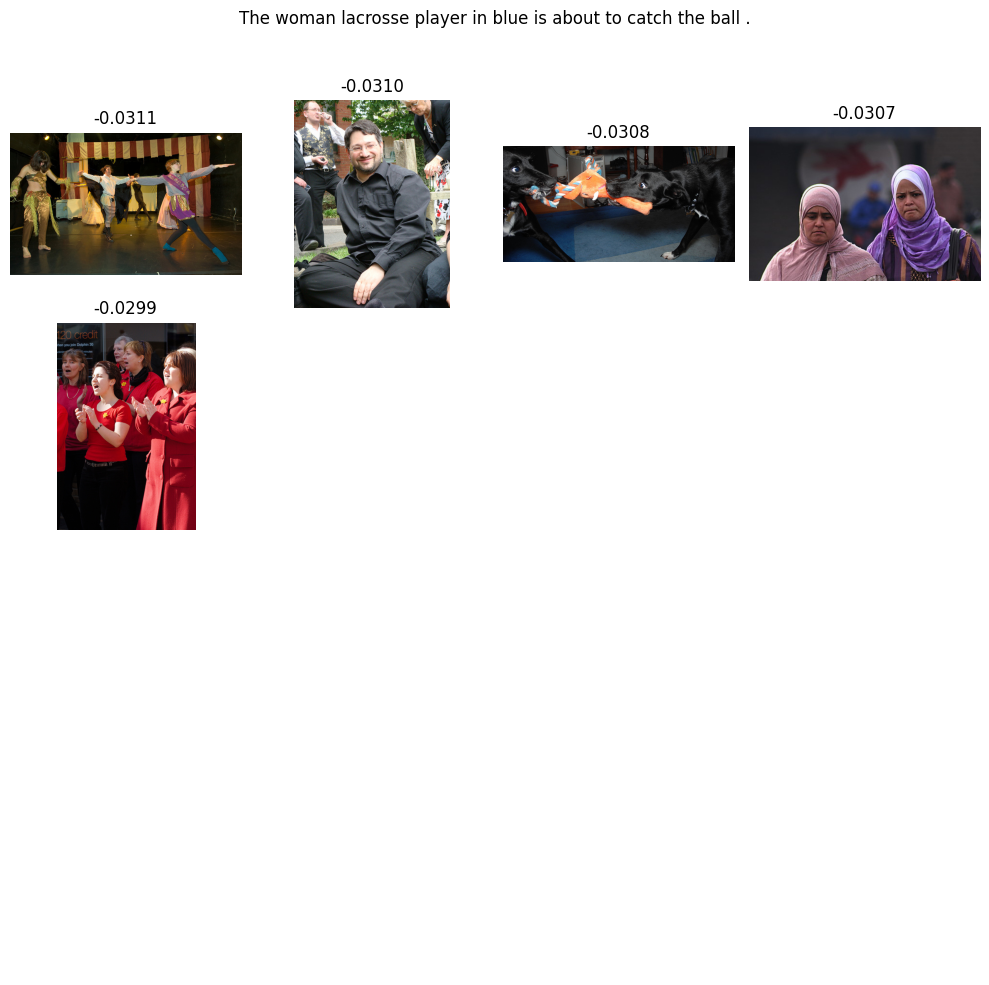

In [65]:
test(["The woman lacrosse player in blue is about to catch the ball ."])

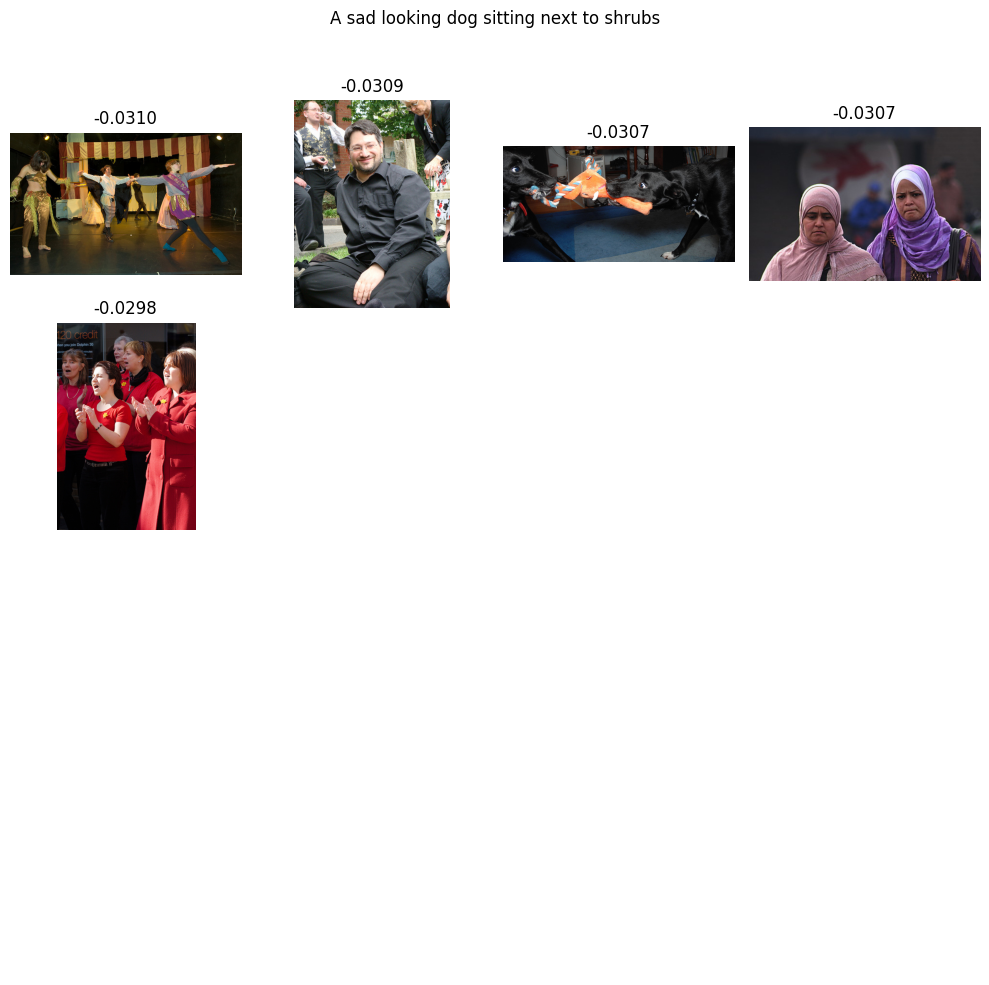

In [66]:
test(["A sad looking dog sitting next to shrubs"])

### Вывод

Была попытка обучить свои модели друг под друга для лучшей генерации вкеторных признаков, однако какого-то качества я не получил. Посколько решается задача поиска, метрику определить, вероятно, можно только визуально, как сказано в описании проекта. На данный момент я вижу, что она неверояфтно низкая, соответственно, для ее повышения можно испорльзовать готовыен модели в связке: bert + resnet или модель подобную dalle из sentence-transformers. По поводу моделей - я смотрел, они обучаются